# 05 — The model on the real data

`MeanTemplateClassifier` as designed: two prototypes (per-day means of the lactating and the
not-lactating series), swept against the series to be classified, lowest minimum MSE wins.

**The sweep.** Pad the series *and* the prototype with `n` zeros on each side, so each becomes
`pad | data | pad` = `l1 l2 l3` / `r1 r2 r3`. Sweep one against the other over the `2n+1` relative
offsets, from `o = +n` (`r1` on `l2`, `r2` on `l3` — l1 and r3 stick out) to `o = −n`
(`r2` on `l1`, `r3` on `l2`). At every offset take the MSE **over the values that cross** — the
overlapping region of the two padded series — keep the minimum, and predict the prototype with
the smaller minimum.

**Evaluation.** Leave-one-out on the 658 labelled bat-years, sit 300 s. One model, one matrix.


In [1]:
%matplotlib inline
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import LeaveOneGroupOut, LeaveOneOut

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))
from mean_template_classifier import MeanTemplateClassifier

DAYS = [f"Day{i}" for i in range(1, 366)]

real = pd.read_csv(REPO / "data/processed/daily_counts/daily_counts_sit300s.csv")
real["Lactating"] = real["Lactating"].fillna("")
real = real[real["Lactating"].isin(["Yes", "No"])].reset_index(drop=True)
X = real[DAYS].to_numpy(float)
y = (real["Lactating"] == "Yes").to_numpy(int)
groups = real["Bat Id"].to_numpy()

dummy = pd.read_csv(REPO / "data/preview/processed/dummy_data.csv")
vcols = [c for c in dummy.columns if c.lower().startswith("day")]
Xs = dummy[vcols].to_numpy(float)
ys = dummy["pregnant"].to_numpy(int)

print(f"real   : {X.shape[0]} bat-years ({y.sum()} lactating, {len(y)-y.sum()} not), "
      f"{len(np.unique(groups))} individuals")
print(f"sandbox: {Xs.shape[0]} x {Xs.shape[1]} ({ys.sum()} pregnant)")


real   : 658 bat-years (455 lactating, 203 not), 193 individuals
sandbox: 1000 x 180 (500 pregnant)


## Leave-one-out

In [2]:
pred = np.zeros(len(y), dtype=int)
marg = np.empty(len(y))
for tr, te in LeaveOneOut().split(X):
    clf = MeanTemplateClassifier().fit(X[tr], y[tr])
    pred[te] = clf.predict(X[te])
    marg[te] = clf.decision_margins(X[te])

cm = confusion_matrix(y, pred, labels=[0, 1])
acc = accuracy_score(y, pred)
prec = precision_score(y, pred, zero_division=0)
rec = recall_score(y, pred, zero_division=0)
f1 = f1_score(y, pred, zero_division=0)
auc = roc_auc_score(y, marg)
print(f"accuracy {acc:.3f}   precision {prec:.3f}   recall {rec:.3f}   F1 {f1:.3f}   AUC {auc:.3f}")
print(f"majority baseline (always lactating): accuracy {y.mean():.3f}")


accuracy 0.701   precision 0.845   recall 0.695   F1 0.762   AUC 0.700
majority baseline (always lactating): accuracy 0.691


## Confusion matrix

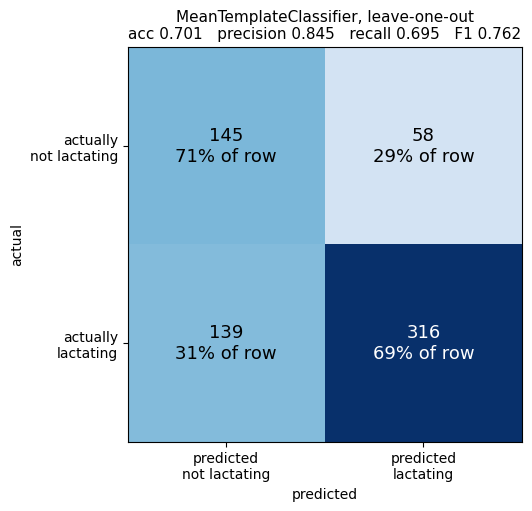

found 316 of 455 lactating bat-years; raised 58 false alarms out of 203 not-lactating


In [3]:
fig, ax = plt.subplots(figsize=(5.8, 5.0), layout="constrained")
ax.imshow(cm, cmap="Blues", vmin=0)
for i in range(2):
    for j in range(2):
        n_ij = cm[i, j]
        ax.text(j, i, f"{n_ij}\n{n_ij / cm[i].sum():.0%} of row", ha="center", va="center",
                fontsize=13, color="white" if n_ij > cm.max() * 0.55 else "black")
ax.set_xticks([0, 1], ["predicted\nnot lactating", "predicted\nlactating"])
ax.set_yticks([0, 1], ["actually\nnot lactating", "actually\nlactating"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
ax.set_title(f"MeanTemplateClassifier, leave-one-out\n"
             f"acc {acc:.3f}   precision {prec:.3f}   recall {rec:.3f}   F1 {f1:.3f}",
             fontsize=11)
plt.show()
print(f"found {cm[1,1]} of {cm[1].sum()} lactating bat-years; "
      f"raised {cm[0,1]} false alarms out of {cm[0].sum()} not-lactating")


## Onset — the by-product of the sweep

The winning offset localises where the elevated phase starts, which is why the sweep is kept on.


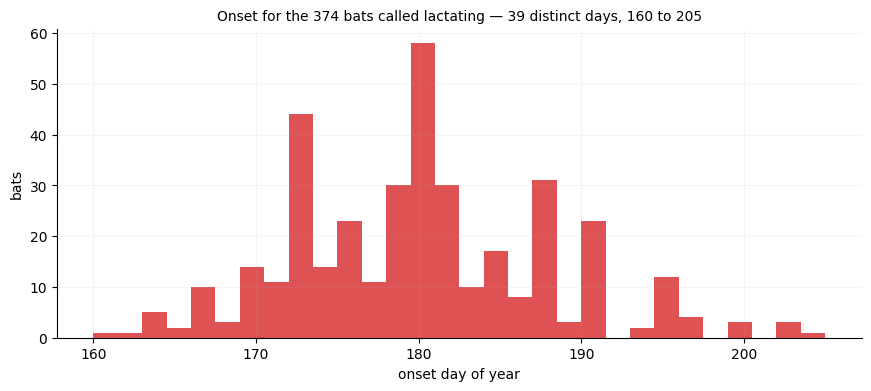

In [4]:
onsets = np.full(len(y), np.nan)
for tr, te in LeaveOneOut().split(X):
    clf = MeanTemplateClassifier().fit(X[tr], y[tr])
    _, o = clf.predict(X[te], onset=True)
    onsets[te] = o
valid = onsets[~np.isnan(onsets)]

fig, ax = plt.subplots(figsize=(8.6, 3.8), layout="constrained")
ax.hist(valid, bins=30, color="tab:red", alpha=.8)
ax.set_xlabel("onset day of year"); ax.set_ylabel("bats")
ax.set_title(f"Onset for the {len(valid)} bats called lactating "
             f"— {len(np.unique(valid))} distinct days, {valid.min():.0f} to {valid.max():.0f}",
             fontsize=10)
ax.grid(alpha=.15, lw=.6); ax.spines[["top", "right"]].set_visible(False)
plt.show()


## Sanity check on the synthetic sandbox

Same model, same code path, on the data the method was developed against.


In [5]:
sandbox = []
for mo in (0.0, 1.0):
    p = np.zeros(len(ys), dtype=int)
    for tr, te in LeaveOneOut().split(Xs):
        p[te] = MeanTemplateClassifier(min_overlap=mo).fit(Xs[tr], ys[tr]).predict(Xs[te])
    sandbox.append(dict(min_overlap=mo, leave_one_out_acc=accuracy_score(ys, p)))
display(pd.DataFrame(sandbox).set_index("min_overlap").round(3))

# does the group structure matter here? (same bat, several years)
p = np.zeros(len(y), dtype=int)
for tr, te in LeaveOneGroupOut().split(X, y, groups):
    p[te] = MeanTemplateClassifier().fit(X[tr], y[tr]).predict(X[te])
print(f"real data, leave-one-INDIVIDUAL-out accuracy: {accuracy_score(y, p):.3f} "
      f"(leave-one-row-out was {acc:.3f})")


,leave_one_out_acc
min_overlap,
0.0,0.999
1.0,0.992


real data, leave-one-INDIVIDUAL-out accuracy: 0.701 (leave-one-row-out was 0.701)


## Appendix — the earlier implementation, for the record

The first version of the code did not implement the sweep above: it padded only the series and
slid a *fixed length-n window*, comparing the whole prototype against that window. At the extreme
offsets that window contains only padding, so the score collapsed to `mean(P²)` — a constant with
no bat in it — and the model called everything "not lactating" (accuracy 0.310, F1 0.004).

Kept here because the contrast is the clearest proof that the current sweep is doing what it
should. The corrected geometry never has this problem: at the end offsets the crossing is one
series' data against the other's padding, which scores badly and loses.


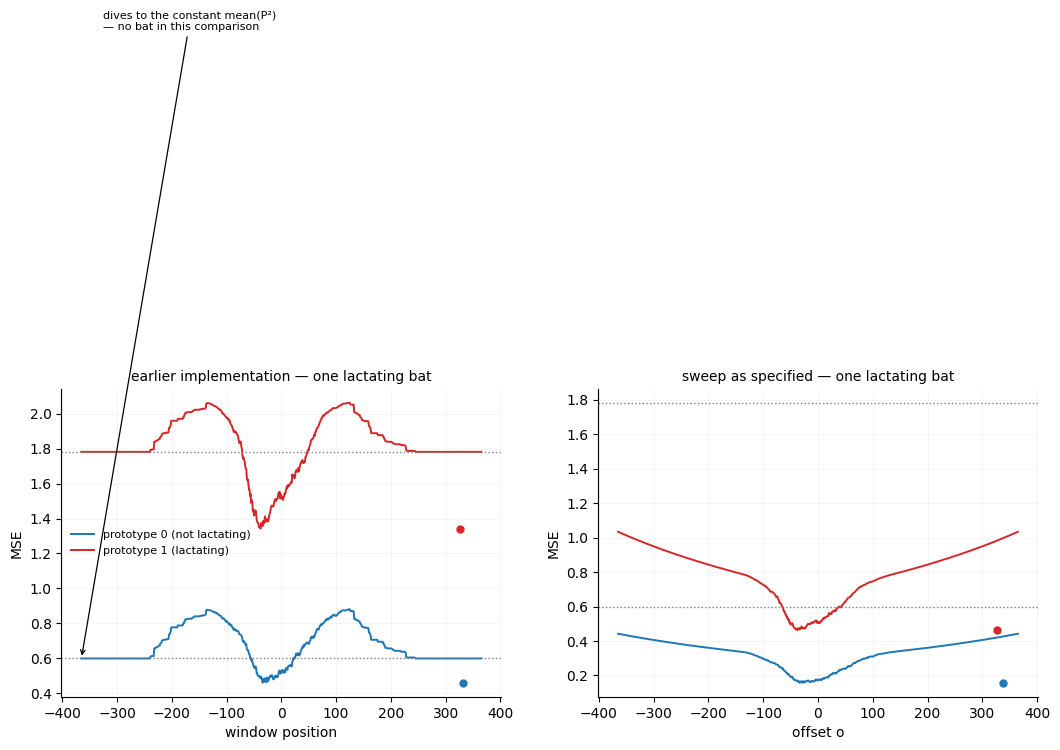

earlier implementation: acc 0.310, confusion TN/FP/FN/TP = 203/0/454/1


In [6]:
def legacy_curves(x, P, n):
    padded = np.concatenate([np.zeros(n), x, np.zeros(n)])
    windows = sliding_window_view(padded, n)          # (2n+1, n)
    return ((windows - P) ** 2).mean(axis=1)


n = X.shape[1]
clf_full = MeanTemplateClassifier().fit(X, y)
k_lac = int(np.flatnonzero(y == 1)[0])
offsets = np.arange(-n, n + 1)

fig, axs = plt.subplots(1, 2, figsize=(12.6, 4.4))
fig.subplots_adjust(wspace=0.22, bottom=0.18, top=0.88)
x = X[k_lac]
for col, (kind, curves, xlabel) in enumerate([
        ("earlier implementation", [legacy_curves(x, clf_full.mean_0_, n),
                                    legacy_curves(x, clf_full.mean_1_, n)], "window position"),
        ("sweep as specified", list(clf_full._mse_curves(x)), "offset o")]):
    ax = axs[col]
    for m, lbl, c in zip(curves, ["prototype 0 (not lactating)", "prototype 1 (lactating)"],
                         ["tab:blue", "tab:red"]):
        j = int(m.argmin())
        ax.plot(offsets, m, color=c, lw=1.4, label=lbl)
        ax.plot(j, m[j], "o", color=c, ms=5)
    ax.axhline(clf_full.mean_0_ @ clf_full.mean_0_ / n, color="gray", ls=":", lw=1)
    ax.axhline(clf_full.mean_1_ @ clf_full.mean_1_ / n, color="gray", ls=":", lw=1)
    ax.set_title(f"{kind} — one lactating bat", fontsize=10)
    ax.set_xlabel(xlabel); ax.set_ylabel("MSE")
    ax.grid(alpha=.15, lw=.6); ax.spines[["top", "right"]].set_visible(False)
axs[0].legend(frameon=False, fontsize=8)
axs[0].annotate("dives to the constant mean(P²)\n— no bat in this comparison",
                xy=(-n, clf_full.mean_0_ @ clf_full.mean_0_ / n), xytext=(-n + 40, 4.2),
                fontsize=8, arrowprops=dict(arrowstyle="->", lw=.9))
plt.show()

# what the earlier implementation scores
pred_l = np.zeros(len(y), dtype=int)
for tr, te in LeaveOneOut().split(X):
    m = X.shape[1]
    P0, P1 = X[tr][y[tr] == 0].mean(axis=0), X[tr][y[tr] == 1].mean(axis=0)
    a = legacy_curves(X[te][0], P0, m).min(); b = legacy_curves(X[te][0], P1, m).min()
    pred_l[te] = int(b < a)
cm_l = confusion_matrix(y, pred_l, labels=[0, 1])
print(f"earlier implementation: acc {accuracy_score(y, pred_l):.3f}, "
      f"confusion TN/FP/FN/TP = {cm_l[0,0]}/{cm_l[0,1]}/{cm_l[1,0]}/{cm_l[1,1]}")


## Verdict

| | acc | precision | recall | F1 | AUC |
|---|---|---|---|---|---|
| this model, leave-one-out | 0.701 | 0.845 | 0.695 | 0.762 | 0.700 |
| always predict lactating | 0.691 | 0.691 | 1.000 | 0.818 | 0.500 |

Confusion matrix 145 / 58 / 139 / 316: it finds **316 of 455** lactating bat-years.

* leave-one-**individual**-out is identical to leave-one-row-out, so no bat is leaking across folds.
* sandbox accuracy 0.999 with the same code path.
* the residual error is amplitude-driven rather than shape-driven — ranking by normalised
  cross-correlation reaches AUC ≈ 0.76 versus 0.70 here. That is the next lever.
